# EDA - Zomato Delivery Dataset
Imran Ahmed | SE 489 MLOps | Food on the Fly

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
(PROJECT_ROOT / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'Zomato Dataset.csv')
print(df.shape)
df.head()

(45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


## target distribution

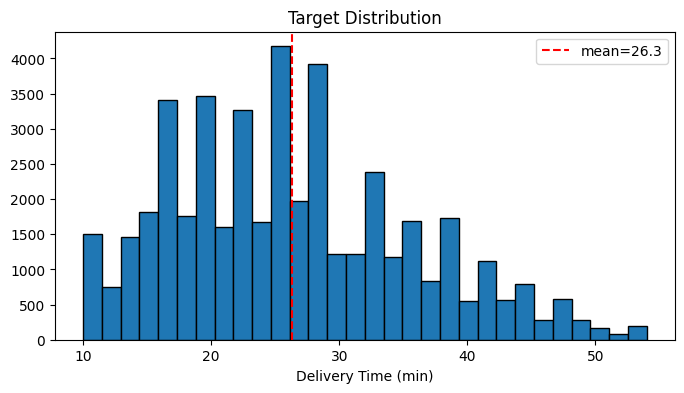

In [21]:
# check how delivery times are distributed and if there are outliers

target = df['Time_taken (min)']

plt.figure(figsize=(8, 4))
plt.hist(target, bins=30, edgecolor='black')
plt.axvline(target.mean(), color='red', linestyle='--', label=f'mean={target.mean():.1f}')
plt.xlabel('Delivery Time (min)')
plt.title('Target Distribution')
plt.legend()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'target_distribution.png', dpi=150)
plt.show()

# 10-54 min range, mean ~26, slight right skew, no zero-min outliers

## delivery time by traffic and vehicle

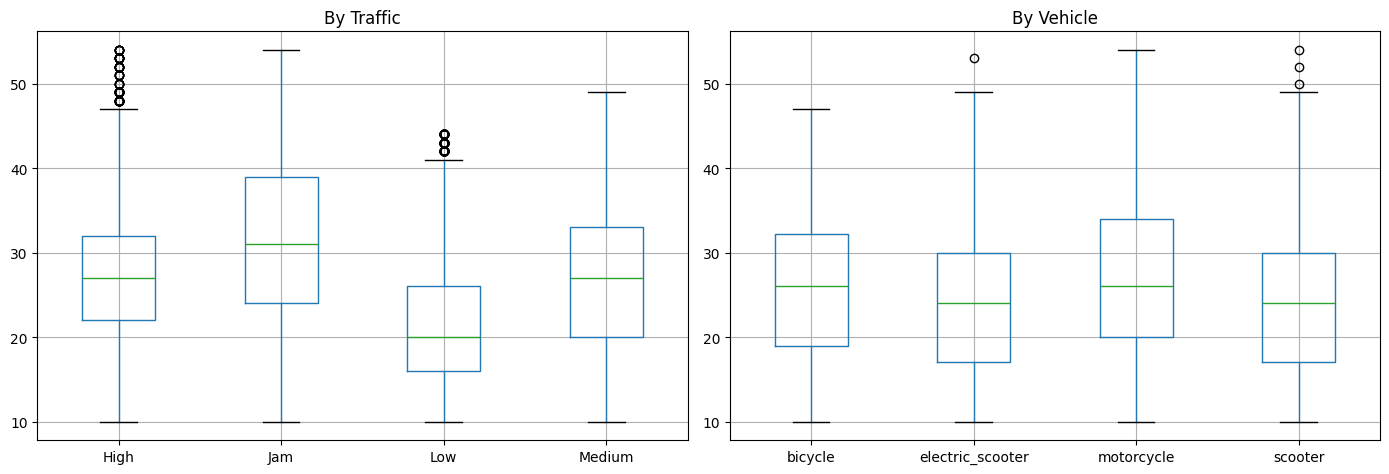

In [22]:
# see how delivery time changes by traffic and vehicle type
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Time_taken (min)', by='Road_traffic_density', ax=ax1)
ax1.set_title('By Traffic')
ax1.set_xlabel('')

df.boxplot(column='Time_taken (min)', by='Type_of_vehicle', ax=ax2)
ax2.set_title('By Vehicle')
ax2.set_xlabel('')

plt.suptitle('')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'target_by_category.png', dpi=150)
plt.show()

# jam traffic = longer times, motorcycles fastest

## distance vs delivery time

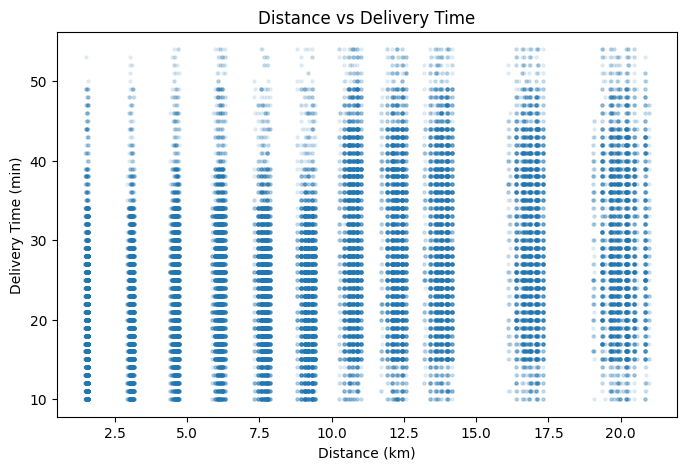

In [23]:
# check if distance between restaurant and drop-off affects delivery time
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(
    df['Restaurant_latitude'], df['Restaurant_longitude'],
    df['Delivery_location_latitude'], df['Delivery_location_longitude']
)

# some lat/long values are clearly wrong (5000+ km deliveries)
# filtering to under 50 km for the plot
df_plot = df[df['distance_km'] < 50]

plt.figure(figsize=(8, 5))
plt.scatter(df_plot['distance_km'], df_plot['Time_taken (min)'], alpha=0.1, s=5)
plt.xlabel('Distance (km)')
plt.ylabel('Delivery Time (min)')
plt.title('Distance vs Delivery Time')
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'distance_vs_time.png', dpi=150)
plt.show()

## correlation heatmap

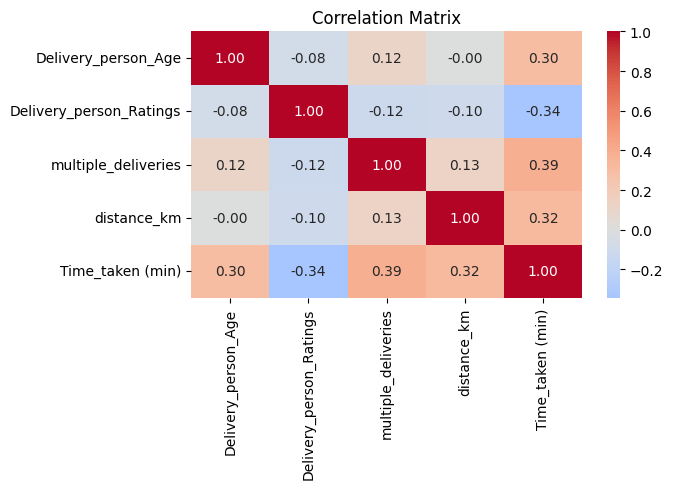

In [24]:
# see which numeric features correlate with delivery time
df_clean = df[df['distance_km'] < 50]
corr_cols = ['Delivery_person_Age', 'Delivery_person_Ratings',
             'multiple_deliveries', 'distance_km', 'Time_taken (min)']

plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'reports' / 'figures' / 'correlation_heatmap.png', dpi=150)
plt.show()

## takeaways

- target ranges 10-54 min, mean ~26, no zero-min outliers
- jam traffic and high density = longer deliveries
- distance correlates positively with time but noisy
- missing values all under 5%
- 54-day window, feb 11 - apr 6 2022